In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv('../data/Bengaluru_House_Data.csv')

In [4]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df.shape

(13320, 9)

In [6]:
df.sample(5)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
10767,Super built-up Area,19-Dec,JP Nagar,2 BHK,Shestut,1300,2.0,1.0,91.65
813,Super built-up Area,17-Jul,Anandapura,2 BHK,ViensRK,1141,2.0,1.0,42.79
7645,Super built-up Area,18-Feb,Varthur,2 BHK,HioraTr,1085,2.0,1.0,45.00
7510,Super built-up Area,Ready To Move,Kambipura,3 BHK,Prrtht,1082,2.0,1.0,45.50
9635,Built-up Area,19-Dec,Kanakapura,2 BHK,GoityEt,1017,2.0,1.0,66.00


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [8]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [9]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [10]:
df.duplicated().sum()

np.int64(529)

In [14]:
df = df.drop_duplicates()

In [15]:
df.rename(columns={"price": "price(in lakhs)", "bath": "bathrooms"}, inplace=True)

In [16]:
df.isnull().sum()

area_type             0
availability          0
location              1
size                 16
society            5328
total_sqft            0
bathrooms            73
balcony             605
price(in lakhs)       0
dtype: int64

In [17]:
df.drop(columns=['society'], inplace=True)

In [18]:
df.head()

,area_type,availability,location,size,total_sqft,bathrooms,balcony,price(in lakhs)
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [19]:
df['bhk'] = df['size'].str.extract(r'(\d+)').astype(float)

In [20]:
df.head()

,area_type,availability,location,size,total_sqft,bathrooms,balcony,price(in lakhs),bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,2.0


In [21]:
df.drop(columns=['size'], inplace=True)

In [22]:
df.head()

,area_type,availability,location,total_sqft,bathrooms,balcony,price(in lakhs),bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2.0


In [23]:
df['availability'].unique()

<ArrowStringArray>
[              '19-Dec',        'Ready To Move',               '18-May',
               '18-Feb',               '18-Nov',               '20-Dec',
               '17-Oct',               '21-Dec',               '19-Sep',
               '20-Sep',               '18-Mar',               '20-Feb',
               '18-Apr',               '20-Aug',               '18-Oct',
               '19-Mar',               '17-Sep',               '18-Dec',
               '17-Aug',               '19-Apr',               '18-Jun',
               '22-Dec',               '22-Jan',               '18-Aug',
               '19-Jan',               '17-Jul',               '18-Jul',
               '21-Jun',               '20-May',               '19-Aug',
               '18-Sep',               '17-May',               '17-Jun',
               '21-May',               '18-Jan',               '20-Mar',
               '17-Dec',               '16-Mar',               '19-Jun',
               '22-Jun',        

In [24]:
df['area_type'].unique()

<ArrowStringArray>
['Super built-up  Area', 'Plot  Area', 'Built-up  Area', 'Carpet  Area']
Length: 4, dtype: str

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 12791 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area_type        12791 non-null  str    
 1   availability     12791 non-null  str    
 2   location         12790 non-null  str    
 3   total_sqft       12791 non-null  str    
 4   bathrooms        12718 non-null  float64
 5   balcony          12186 non-null  float64
 6   price(in lakhs)  12791 non-null  float64
 7   bhk              12775 non-null  float64
dtypes: float64(4), str(4)
memory usage: 1.4 MB


In [26]:
df.shape

(12791, 8)

In [27]:
df['location'] = df['location'].fillna(df['location'].mode()[0])
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bhk'] = df['bhk'].fillna(df['bhk'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

In [28]:
df.isnull().sum()

area_type          0
availability       0
location           0
total_sqft         0
bathrooms          0
balcony            0
price(in lakhs)    0
bhk                0
dtype: int64

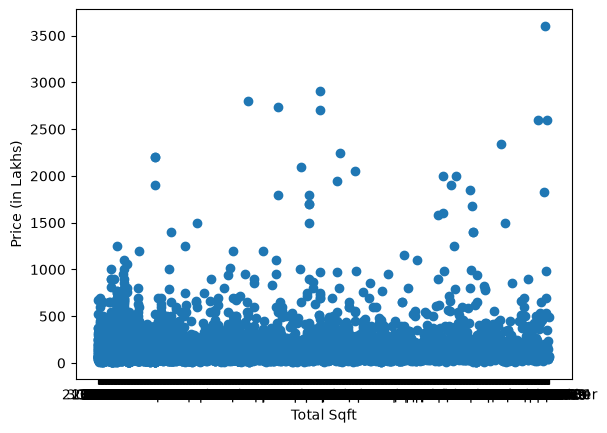

In [29]:
plt.scatter(df['total_sqft'], df['price(in lakhs)'])
plt.xlabel('Total Sqft')
plt.ylabel('Price (in Lakhs)')
plt.show()

In [30]:
df.head()

,area_type,availability,location,total_sqft,bathrooms,balcony,price(in lakhs),bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2.0


In [33]:
df['bathrooms'].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9.,  8.,  7., 11., 10., 14., 27.,
       12., 16., 40., 15., 13., 18.])

In [34]:
df['balcony'].unique()

array([1., 3., 2., 0.])

In [35]:
df['bhk'].unique()

array([ 2.,  4.,  3.,  6.,  1.,  8.,  7.,  5., 11.,  9., 27., 10., 19.,
       16., 43., 14., 12., 13., 18.])

In [36]:
df['location'].unique()

<ArrowStringArray>
[                       'Electronic City Phase II',
                                'Chikka Tirupathi',
                                     'Uttarahalli',
                              'Lingadheeranahalli',
                                        'Kothanur',
                                      'Whitefield',
                                'Old Airport Road',
                                    'Rajaji Nagar',
                                    'Marathahalli',
                                    'Gandhi Bazar',
 ...
                               'Masjid e Alkareem',
                                   'Sindhi Colony',
                             'Kanakapur main road',
                       'Prasanna layout Herohalli',
                               'Sarvobhogam Nagar',
                                  'Pattegarhpalya',
                                     'Tilak Nagar',
 '12th cross srinivas nagar banshankari 3rd stage',
                               'Havanur 

In [37]:
df['total_sqft'].apply(lambda x: isinstance(x, str)).sum()

np.int64(12791)

In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 12791 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area_type        12791 non-null  str    
 1   availability     12791 non-null  str    
 2   location         12791 non-null  str    
 3   total_sqft       12791 non-null  str    
 4   bathrooms        12791 non-null  float64
 5   balcony          12791 non-null  float64
 6   price(in lakhs)  12791 non-null  float64
 7   bhk              12791 non-null  float64
dtypes: float64(4), str(4)
memory usage: 1.4 MB


In [39]:
df['total_sqft'].sample(20)

9523     2000
13088    1290
4415     1760
9101     1000
9143     1352
5        1170
3494     1500
11435    2800
12690    1265
1836     1258
115      2497
13259    1477
1772     2000
10821    1339
782       445
1410      900
4001     1440
5753     1233
7109     1145
2810     1020
Name: total_sqft, dtype: str

In [40]:
df[df['total_sqft'].str.contains('-', na=False)]

,area_type,availability,location,total_sqft,bathrooms,balcony,price(in lakhs),bhk
30,Super built-up Area,19-Dec,Yelahanka,2100 - 2850,4.0,0.0,186.000,4.0
56,Built-up Area,20-Feb,Devanahalli,3010 - 3410,2.0,2.0,192.000,4.0
81,Built-up Area,18-Oct,Hennur Road,2957 - 3450,2.0,2.0,224.500,4.0
122,Super built-up Area,18-Mar,Hebbal,3067 - 8156,4.0,0.0,477.000,4.0
137,Super built-up Area,19-Mar,8th Phase JP Nagar,1042 - 1105,2.0,0.0,54.005,2.0
...,...,...,...,...,...,...,...,...
12975,Super built-up Area,20-Aug,Whitefield,850 - 1060,2.0,0.0,38.190,2.0
12990,Super built-up Area,18-May,Talaghattapura,1804 - 2273,3.0,0.0,122.000,3.0
13059,Super built-up Area,Ready To Move,Harlur,1200 - 1470,2.0,0.0,72.760,2.0
13240,Super built-up Area,Ready To Move,Devanahalli,1020 - 1130,2.0,2.0,52.570,1.0


In [41]:
df[df['total_sqft'].str.contains('[a-zA-Z]', na=False)]

,area_type,availability,location,total_sqft,bathrooms,balcony,price(in lakhs),bhk
410,Super built-up Area,Ready To Move,Kengeri,34.46Sq. Meter,1.0,0.0,18.50,1.0
648,Built-up Area,Ready To Move,Arekere,4125Perch,9.0,2.0,265.00,9.0
775,Built-up Area,Ready To Move,Basavanagara,1000Sq. Meter,2.0,1.0,93.00,1.0
872,Super built-up Area,Ready To Move,Singapura Village,1100Sq. Yards,2.0,2.0,45.00,2.0
1019,Plot Area,18-Mar,Marathi Layout,5.31Acres,1.0,0.0,110.00,1.0
1086,Plot Area,19-Mar,Narasapura,30Acres,2.0,2.0,29.50,2.0
1400,Super built-up Area,Ready To Move,Chamrajpet,716Sq. Meter,9.0,1.0,296.00,9.0
1712,Plot Area,Ready To Move,Singena Agrahara,1500Sq. Meter,3.0,1.0,95.00,3.0
1743,Super built-up Area,19-Mar,Hosa Road,142.61Sq. Meter,3.0,1.0,115.00,3.0
1821,Plot Area,Ready To Move,Sarjapur,1574Sq. Yards,3.0,1.0,76.00,3.0


In [42]:
df = df[~df['total_sqft'].str.contains('[a-zA-Z]', na=False)]

In [43]:
def convert_sqft(x):
    if '-' in x:
        vals = x.split('-')
        return (float(vals[0]) + float(vals[1])) / 2
    else:
        return float(x)

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [44]:
df.info()

<class 'pandas.DataFrame'>
Index: 12745 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area_type        12745 non-null  str    
 1   availability     12745 non-null  str    
 2   location         12745 non-null  str    
 3   total_sqft       12745 non-null  float64
 4   bathrooms        12745 non-null  float64
 5   balcony          12745 non-null  float64
 6   price(in lakhs)  12745 non-null  float64
 7   bhk              12745 non-null  float64
dtypes: float64(5), str(3)
memory usage: 1.4 MB


In [45]:
df.head()

,area_type,availability,location,total_sqft,bathrooms,balcony,price(in lakhs),bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2.0


In [46]:
df.shape

(12745, 8)

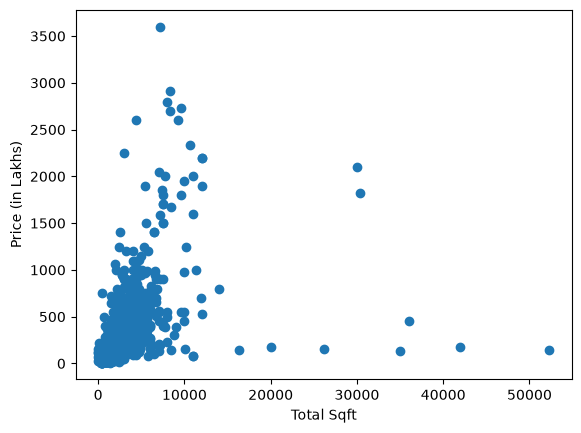

In [47]:
plt.scatter(df['total_sqft'], df['price(in lakhs)'])
plt.xlabel('Total Sqft')
plt.ylabel('Price (in Lakhs)')
plt.show()

In [48]:
df['availability'] = df['availability'].apply(lambda x: 1 if x == 'Ready To Move' or x == 'Immediate Possession' else 0)

In [49]:
df.head()

,area_type,availability,location,total_sqft,bathrooms,balcony,price(in lakhs),bhk
0,Super built-up Area,0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,1,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,1,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,1,Kothanur,1200.0,2.0,1.0,51.00,2.0


In [50]:
df['bhk'].unique()

array([ 2.,  4.,  3.,  6.,  1.,  8.,  7.,  5., 11.,  9., 27., 10., 19.,
       16., 43., 14., 12., 13., 18.])

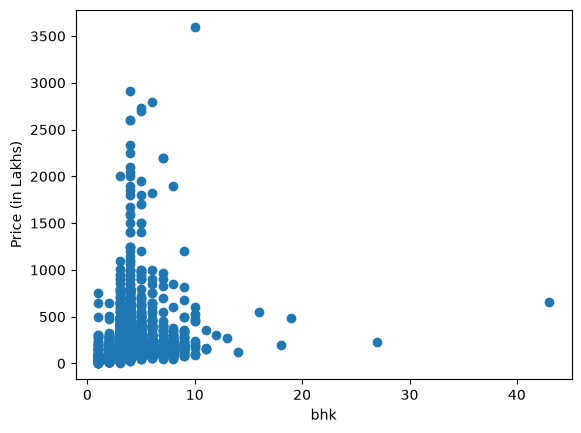

In [51]:
plt.scatter(df['bhk'], df['price(in lakhs)'])
plt.xlabel('bhk')
plt.ylabel('Price (in Lakhs)')
plt.show()

In [52]:
(df['bhk'] > 10).sum()

np.int64(12)

In [53]:
df = df[df['bhk'] <= 10]

In [54]:
df.shape

(12733, 8)

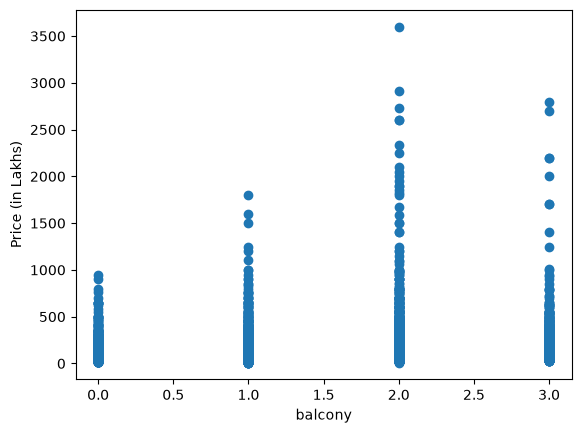

In [55]:
plt.scatter(df['balcony'], df['price(in lakhs)'])
plt.xlabel('balcony')
plt.ylabel('Price (in Lakhs)')
plt.show()

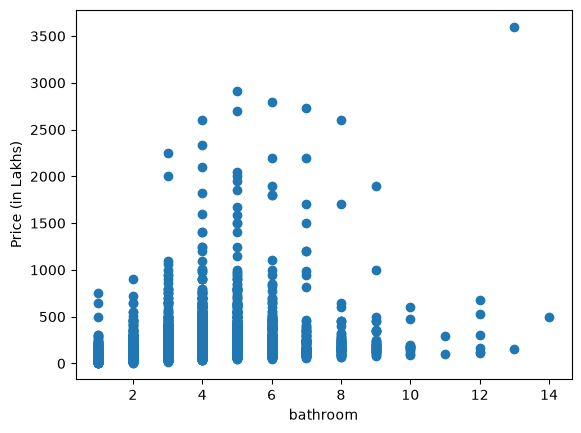

In [56]:
plt.scatter(df['bathrooms'], df['price(in lakhs)'])
plt.xlabel('bathroom')
plt.ylabel('Price (in Lakhs)')
plt.show()

In [57]:
(df['bathrooms'] > 10).sum()

np.int64(11)

In [58]:
df = df[df['bathrooms'] <= 10]

In [59]:
df.shape

(12722, 8)

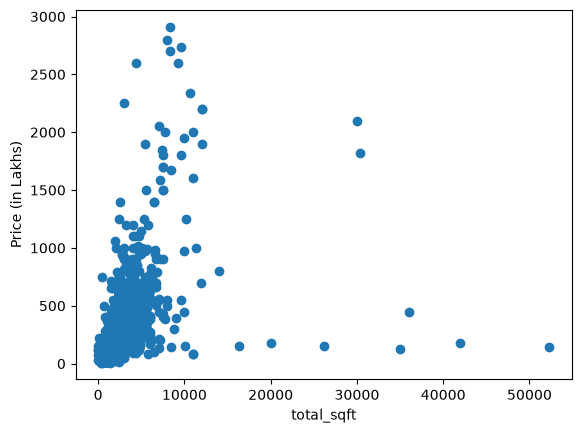

In [60]:
plt.scatter(df['total_sqft'], df['price(in lakhs)'])
plt.xlabel('total_sqft')
plt.ylabel('Price (in Lakhs)')
plt.show()

In [61]:
(df['total_sqft'] > 10000).sum()

np.int64(22)

In [62]:
(df['total_sqft'] > 15000).sum()

np.int64(9)

In [63]:
(df['total_sqft'] > 20000).sum()

np.int64(7)

In [64]:
df = df[df['total_sqft'] <= 10000]

In [65]:
df.shape

(12700, 8)

In [66]:
df.head()

,area_type,availability,location,total_sqft,bathrooms,balcony,price(in lakhs),bhk
0,Super built-up Area,0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,1,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,1,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,1,Kothanur,1200.0,2.0,1.0,51.00,2.0


In [67]:
df['location'].value_counts()

location
Whitefield                                         520
Sarjapur  Road                                     379
Electronic City                                    286
Kanakpura Road                                     247
Thanisandra                                        228
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1286, dtype: int64

In [68]:
df['location'].value_counts().describe()

count    1286.000000
mean        9.875583
std        28.222050
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       520.000000
Name: count, dtype: float64

In [69]:
(df['location'].value_counts() < 10).sum()

np.int64(1039)

In [70]:
location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts < 10].index
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

In [71]:
df.head()

,area_type,availability,location,total_sqft,bathrooms,balcony,price(in lakhs),bhk
0,Super built-up Area,0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,1,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,1,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,1,Kothanur,1200.0,2.0,1.0,51.00,2.0


In [72]:
df.sample(10)

,area_type,availability,location,total_sqft,bathrooms,balcony,price(in lakhs),bhk
1695,Built-up Area,1,other,1410.0,2.0,3.0,67.00,2.0
8522,Super built-up Area,0,Kanakpura Road,700.0,2.0,1.0,35.00,2.0
8904,Super built-up Area,1,Ambalipura,1625.0,2.0,2.0,145.00,3.0
4209,Super built-up Area,1,Raja Rajeshwari Nagar,1128.0,2.0,1.0,48.79,2.0
3913,Super built-up Area,1,Whitefield,1205.0,2.0,1.0,40.00,2.0
8628,Super built-up Area,1,Lingadheeranahalli,1506.0,3.0,1.0,95.00,3.0
12401,Built-up Area,1,other,1300.0,3.0,1.0,65.00,2.0
9704,Super built-up Area,1,Banashankari,1372.0,2.0,2.0,48.02,3.0
8973,Built-up Area,1,Hennur,1640.0,3.0,2.0,120.00,3.0
2876,Plot Area,1,other,1272.0,4.0,0.0,75.00,3.0


In [73]:
df['price_per_sqft'] = df['price(in lakhs)'] * 100000 / df['total_sqft']
df.head()

,area_type,availability,location,total_sqft,bathrooms,balcony,price(in lakhs),bhk,price_per_sqft
0,Super built-up Area,0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0,3699.810606
1,Plot Area,1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0,4615.384615
2,Built-up Area,1,Uttarahalli,1440.0,2.0,3.0,62.00,3.0,4305.555556
3,Super built-up Area,1,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0,6245.890861
4,Super built-up Area,1,Kothanur,1200.0,2.0,1.0,51.00,2.0,4250.000000


In [74]:
def remove_pps_outliers(df):
    out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = subdf['price_per_sqft'].mean()
        st = subdf['price_per_sqft'].std()
        reduced = subdf[(subdf['price_per_sqft'] > (m - st)) & (subdf['price_per_sqft'] <= (m + st))]
        out = pd.concat([out, reduced], ignore_index=True)
    return out

df = remove_pps_outliers(df)
df.shape

(11004, 9)

In [75]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': bhk_df['price_per_sqft'].mean(),
                'std': bhk_df['price_per_sqft'].std(),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk - 1)
            if stats and stats['count'] > 5:
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[bhk_df['price_per_sqft'] < stats['mean']].index.values
                )
    return df.drop(exclude_indices, axis='index')

df = remove_bhk_outliers(df)
df.shape

(7774, 9)

In [76]:
df = df[df['bathrooms'] < df['bhk'] + 2]
df.shape

(7675, 9)

In [77]:
df = df.drop(columns=['price_per_sqft'])
df.head()

,area_type,availability,location,total_sqft,bathrooms,balcony,price(in lakhs),bhk
1,Super built-up Area,1,Devarachikkanahalli,1250.0,2.0,2.0,40.0,2.0
2,Plot Area,1,Devarachikkanahalli,1200.0,2.0,2.0,83.0,2.0
3,Super built-up Area,1,Devarachikkanahalli,1170.0,2.0,2.0,40.0,2.0
4,Super built-up Area,1,Devarachikkanahalli,1425.0,2.0,2.0,65.0,3.0
5,Super built-up Area,1,Devarachikkanahalli,947.0,2.0,2.0,43.0,2.0


In [78]:
df.shape

(7675, 8)

In [85]:
from sklearn.model_selection import train_test_split

X = df.drop('price(in lakhs)', axis=1)
y = np.log1p(df['price(in lakhs)'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
X_train.shape

(6140, 7)

In [87]:
X_test.shape

(1535, 7)

In [88]:
y_train.shape

(6140,)

In [89]:
y_test.shape

(1535,)

In [90]:
X_train.head()

,area_type,availability,location,total_sqft,bathrooms,balcony,bhk
570,Built-up Area,1,Attibele,395.0,1.0,1.0,1.0
6051,Built-up Area,1,Ramamurthy Nagar,540.0,1.0,0.0,1.0
7277,Super built-up Area,0,Varthur,1180.0,2.0,2.0,2.0
3824,Built-up Area,1,KR Puram,714.0,1.0,1.0,1.0
4536,Super built-up Area,1,Kengeri Satellite Town,1060.0,2.0,3.0,2.0


In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [92]:
ct = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore'), ['area_type', 'location']),
    ('scale', StandardScaler(), ['total_sqft', 'bathrooms', 'balcony', 'bhk']),
], remainder='passthrough')

In [93]:
X_train_transformed = ct.fit_transform(X_train)
X_test_transformed = ct.transform(X_test)

In [94]:
X_test_transformed.shape

(1535, 257)

In [95]:
X_train_transformed.shape

(6140, 257)

In [98]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train_transformed, y_train)
lr_pred = lr.predict(X_test_transformed)
lr_r2 = r2_score(y_test, lr_pred)
print("Linear Regression R2:", lr_r2)

Linear Regression R2: 0.844370710567466


In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr_pred_actual = np.expm1(lr.predict(X_test_transformed))
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, lr_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, lr_pred_actual))

print(f"MAE: {mae:.2f} lakhs")
print(f"RMSE: {rmse:.2f} lakhs")

MAE: 25.86 lakhs
RMSE: 62.78 lakhs


In [103]:
import joblib

joblib.dump(lr, 'price_model.pkl')
joblib.dump(ct, 'column_transformer.pkl')

['column_transformer.pkl']